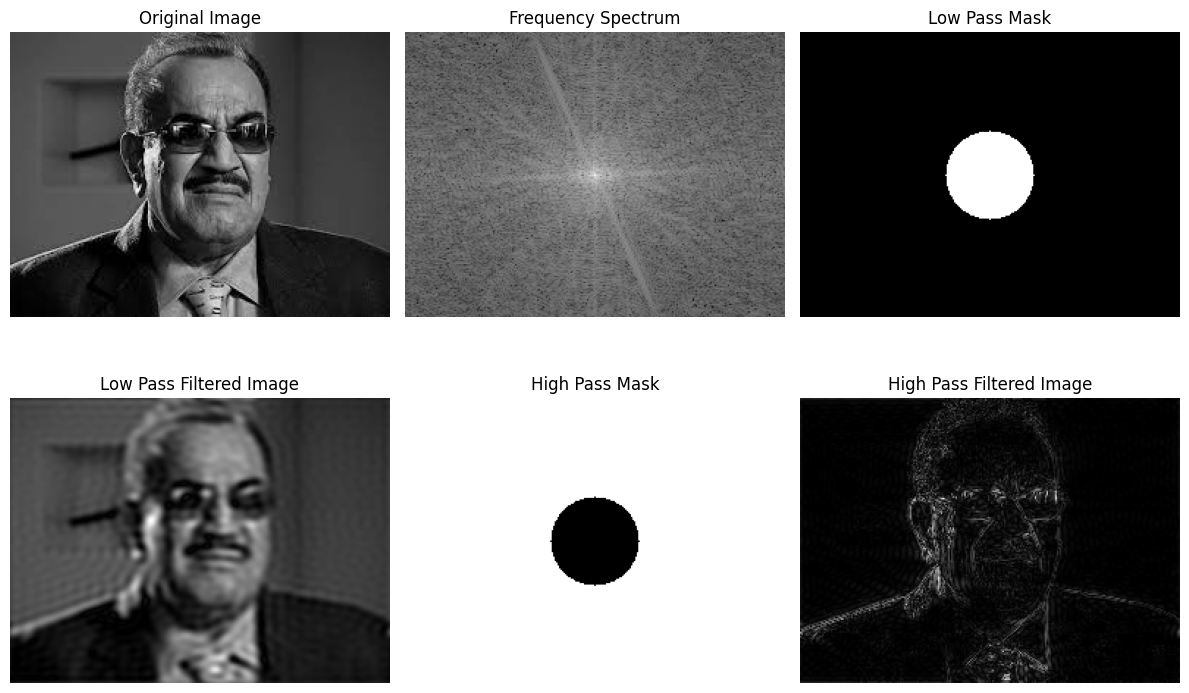

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("download.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found")
    exit()

# Get image dimensions
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Apply DFT
dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)

# ---------------- LOW PASS FILTER ----------------
lpf_mask = np.zeros((rows, cols), np.uint8)
radius = 30
cv2.circle(lpf_mask, (ccol, crow), radius, 1, -1)

# ---------------- HIGH PASS FILTER ----------------
hpf_mask = np.ones((rows, cols), np.uint8)
cv2.circle(hpf_mask, (ccol, crow), radius, 0, -1)

# Apply masks
lpf_dft = dft_shift * lpf_mask
hpf_dft = dft_shift * hpf_mask

# Inverse DFT
lpf_ishift = np.fft.ifftshift(lpf_dft)
hpf_ishift = np.fft.ifftshift(hpf_dft)

lpf_image = np.abs(np.fft.ifft2(lpf_ishift))
hpf_image = np.abs(np.fft.ifft2(hpf_ishift))

# ---------------- PLOTTING ----------------
plt.figure(figsize=(12, 8))

# Original Image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Frequency Spectrum
plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(dft_shift)), cmap='gray')
plt.title("Frequency Spectrum")
plt.axis("off")

# Low Pass Mask
plt.subplot(2, 3, 3)
plt.imshow(lpf_mask, cmap='gray')
plt.title("Low Pass Mask")
plt.axis("off")

# Low Pass Result
plt.subplot(2, 3, 4)
plt.imshow(lpf_image, cmap='gray')
plt.title("Low Pass Filtered Image")
plt.axis("off")

# High Pass Mask
plt.subplot(2, 3, 5)
plt.imshow(hpf_mask, cmap='gray')
plt.title("High Pass Mask")
plt.axis("off")

# High Pass Result
plt.subplot(2, 3, 6)
plt.imshow(hpf_image, cmap='gray')
plt.title("High Pass Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()